In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Question 1:**
Verify that the mean of power is centered around the variance of the voltage.

## **Answer:**
We know that, at the antenna terminals, the incoming electromagnetic radiation induces a voltage which has zero mean and is gaussian. The zero mean comes from the fact that astronomical radiation is incoherent i.e. it is the sum of a huge number of independent emitters.
###                           E[V(t)] = 0

Now since we know that the recieved power is proportional to square of voltage and we can take the constant of proportionality to be constant here.
### P(t) = V^2(t)

Taking expectation on both sides we get,
###E[P] = E[V^2]

Now, towards the question we need to relate the variance of voltage and mean of power.
### Var(V) = E[V^2] - (E[V])^2
Since the astronomical radiation has zero mean, as mentioned above
###                           E[V] = 0
We get the following relation,
### Var(V) = E[V^2] = E[P]

In [2]:
N = 2000000
sigma = 3

V = np.random.normal(0, sigma, N)

P = V**2

variance_voltage = np.var(V)
mean_power = np.mean(P)

print("Theoretical sigma^2:", sigma**2)
print("Variance of voltage:", variance_voltage)
print("Mean power:", mean_power)

Theoretical sigma^2: 9
Variance of voltage: 8.99955676799925
Mean power: 8.999562560622051


## **Question 2:** Consider cases of different RMS and plot their histograms.

## **Answer:**


For a zero-mean Gaussian voltage signal:

𝑉 ∼ 𝑁(0,𝜎^2)


The RMS (Root Mean Square) value is defined as:

RMS = sqrt(𝐸[𝑉^2])

Since: E[V]=0

RMS=
Var(V) =σ

Thus, for a zero-mean Gaussian process:

### RMS = σ

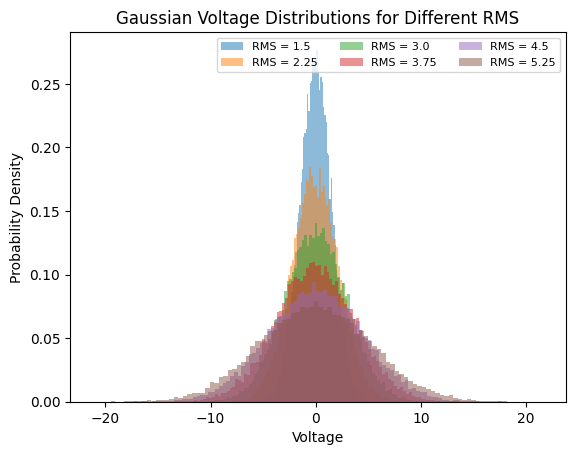

In [13]:
import numpy as np
import matplotlib.pyplot as plt

N = 30000
sigma = np.arange(1.5, 6, 0.75)
plt.figure()

for i in range(len(sigma)):
    V_new = sigma[i] * np.random.randn(N)
    plt.hist(V_new, bins=100, density=True, alpha=0.5,
             label=f"RMS = {sigma[i]}")

plt.xlabel("Voltage")
plt.ylabel("Probability Density")
plt.title("Gaussian Voltage Distributions for Different RMS")
plt.legend(ncol=3, fontsize=8)
plt.show()


From the histogram:


*   All distributions are centered at zero.
*   Smaller RMS → narrow, sharply peaked distribution.
*   Larger RMS → wider distribution with lower peak height.
*   The total area under each curve remains 1 (since they are PDFs).
*   This confirms that increasing RMS increases the spread of the voltage values.

Thus:

*   Larger RMS → larger voltage fluctuations
*   Larger fluctuations → higher variance
*   Higher variance → higher measured power

This demonstrates how RMS directly controls the power measured in radio astronomy.

## **Question 3:** How will the histogram change if I add a slowly varying sine wave in it.

## **Answer:**

Initially, the voltage at the antenna is modeled as Gaussian noise:

### V(t) = N(t)

where:

### N(t) ∼ N(0,σ^2)

The histogram of this signal is a Gaussian distribution:

*   Symmetric about zero

*   Peak at zero

*   Spread determined by :   **𝜎**


Now suppose we add a slowly varying sine wave:

### V(t) = N(t) + Asin(ωt)

This introduces a deterministic coherent component to the random noise.


At any fixed time
𝑡, the signal becomes:

### V(t) ∼ N(Asin(ωt), σ^2)

So the instantaneous mean becomes time-dependent:

### μ(t)=Asin(ωt)

The variance of the noise remains 𝜎^2

Over many samples covering full sine cycles:

### E[sin(ωt)]=0

So overall mean remains zero:
E[V]=0

But the variance changes:

### Var(V) = Var(N) + Var(Asin(ωt))

Since:
Var(N) = σ^2 and E[sin^2(ωt)] = 1/2

we get:

### Var(V) = σ^2 + A^2/2

So adding a sine wave increases the total variance (and therefore mean power).

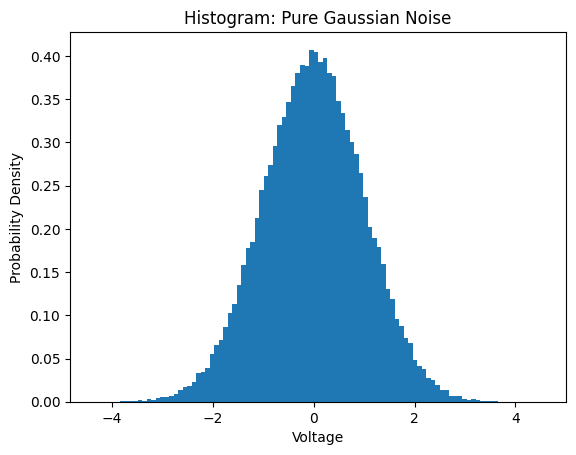

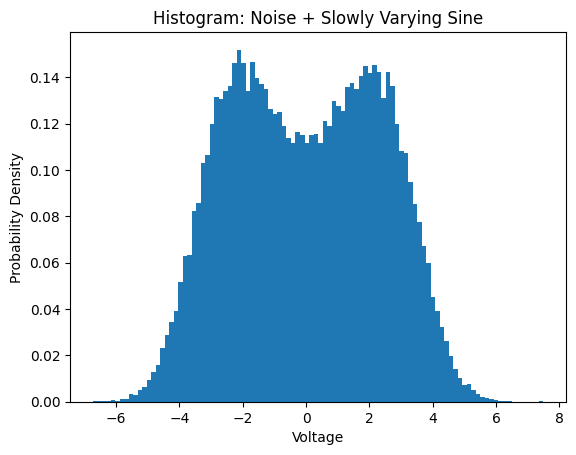

Variance (Noise only): 0.991573903857541
Variance (Noise + Sine): 5.498440566960277
Theoretical Variance (σ² + A²/2): 5.5


In [16]:
N = 50000
sigma = 1.0
A = 3.0
f = 0.05

t = np.linspace(0, 200, N)

noise = np.random.normal(0, sigma, N)
sine_wave = A * np.sin(2 * np.pi * f * t)
V_total = noise + sine_wave

# --- Plot 1: Histogram of Pure Noise ---
plt.figure()
plt.hist(noise, bins=100, density=True)
plt.title("Histogram: Pure Gaussian Noise")
plt.xlabel("Voltage")
plt.ylabel("Probability Density")
plt.show()

# --- Plot 2: Histogram of Noise + Sine ---
plt.figure()
plt.hist(V_total, bins=100, density=True)
plt.title("Histogram: Noise + Slowly Varying Sine")
plt.xlabel("Voltage")
plt.ylabel("Probability Density")
plt.show()

var_noise = np.var(noise)
var_total = np.var(V_total)
theoretical_variance = sigma**2 + (A**2)/2

print("Variance (Noise only):", var_noise)
print("Variance (Noise + Sine):", var_total)
print("Theoretical Variance (σ² + A²/2):", theoretical_variance)


When a slowly varying sine wave is added to Gaussian voltage noise, the instantaneous mean becomes time dependent while the variance of the noise remains unchanged. Over many samples, the histogram becomes a mixture of Gaussians centered at different means, leading to broadening and possible bimodality, if the amplitude of the sine wave is large enough. The total variance increases to
σ^2 + A^2/2, and since mean power equals variance, the measured power increases accordingly.

## **Question 4:** How are the Variances of the ensembles distributed?

## **Answer:**

We have:

𝑀 ensembles and each ensemble contains 𝑁 Gaussian samples

For each ensemble, we compute its sample variance so we obtain: $S_1^2, S_2^2, \dots, S_M^2$

Let the voltage sample be: $V_{ij} \sim \mathcal{N}(0, \sigma^2)$

For each ensemble
𝑖, the unbiased sample variance is: $S_i^2 = \frac{1}{N - 1} \sum_{j=1}^{N} (V_{ij} - \bar{V}_i)^2$

For Gaussian data, it is a known result that: $\frac{(N - 1)S_i^2}{\sigma^2} \sim \chi_{N-1}^2$

Therefore: $S_i^2 \sim \frac{\sigma^2}{N - 1} \chi_{N-1}^2$

$E[S^2] = σ^2$

$Var(S^2) = \frac{2\sigma^4}{N - 1}$

Therefore:

*   For small 𝑁: distribution is wide and skewed.
*   For large 𝑁: distribution becomes narrow.
*   As $N \to \infty$, by Central Limit Theorem, distribution approaches Gaussian.

The spread of the variance estimator decreases as: $\sqrt{Var(S^2)} ∝ \frac{1}{\sqrt{N}}$.

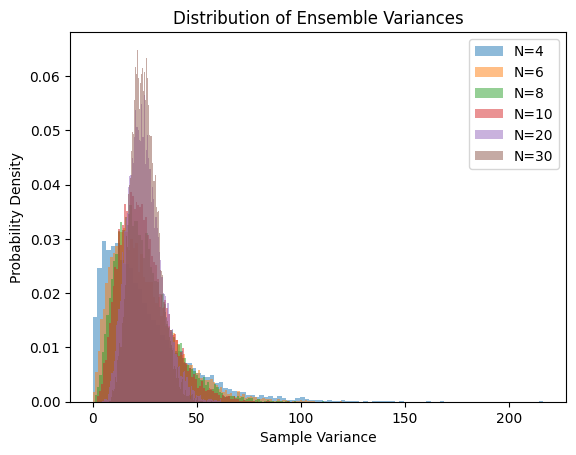

In [30]:
M = 10000
sigma = 5
N_values = [4, 6, 8, 10, 20, 30]

plt.figure()

for N in N_values:
    V = sigma * np.random.randn(M, N)
    sample_var = np.var(V, axis=1, ddof=1)
    plt.hist(sample_var, bins=100, density=True, alpha=0.5, label=f"N={N}")

plt.xlabel("Sample Variance")
plt.ylabel("Probability Density")
plt.title("Distribution of Ensemble Variances")
plt.legend()
plt.show()

For small 𝑁:

* Histogram is right-skewed.

* Wide spread.

* Large fluctuations.

For large 𝑁:

* Histogram becomes narrower.

* More symmetric.

* Cocentrates around $𝜎^2$.

This matches the scaled chi-square behavior.

The variances of Gaussian ensembles:

* Do not follow a Gaussian distribution.

* Follow a scaled chi-square distribution.

* Have mean equal to true variance.

* Have spread proportional to $\frac{1}{\sqrt{N}}$

Thus, increasing number of samples reduces uncertainty in variance estimation.

### Interpretation
The histograms show that the sample variances follow a scaled chi-square distribution. For small N, the distribution is strongly right-skewed with a long tail, indicating large fluctuations in the variance estimate. As N increases, the distribution becomes narrower and more symmetric, concentrating around the true variance $σ^2 = 25$.

Hence verifying, $Var(S^2) = \frac{2\sigma^4}{N-1}$

Thus, increasing the number of samples per ensemble reduces the uncertainty in variance estimation.